# Saliency Maps

In [2]:
import xarray as xr

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients, run_forecast_with_integrated_gradients
from pkg.saliency_maps.plot_gradient import plot_surface_saliency, plot_atmospheric_saliency, plot_field

## Run Forecast

In [ ]:
# load input data
input = xr.open_dataset(
    "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
).load()

# load climatology
climatology = xr.open_dataset(
    "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"
)


### Vanilla and grad_x_input Gradient

In [ ]:
run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=False,
)

### Integrated Gradients

In [ ]:
run_forecast_with_integrated_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    m_steps=1,
    upload_to_gcs=False,
)

## Plot Results

In [3]:
saliency_path = "../data/saliency_maps/zeynep_wind_grad_saliency.nc"

saliency_path_grad_x_input = "../data/saliency_maps/zeynep_wind_grad_grad_x_input.nc"

saliency_path_integrated_gradients = "../data/saliency_maps/zeynep_wind_grad_integrated.nc"

input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"  

sal_ds = xr.open_dataset(saliency_path)
sal_ds_grad_x_input = xr.open_dataset(saliency_path_grad_x_input)
sal_ds_integrated_gradients = xr.open_dataset(saliency_path_integrated_gradients)

input_ds = xr.open_dataset(input_path)


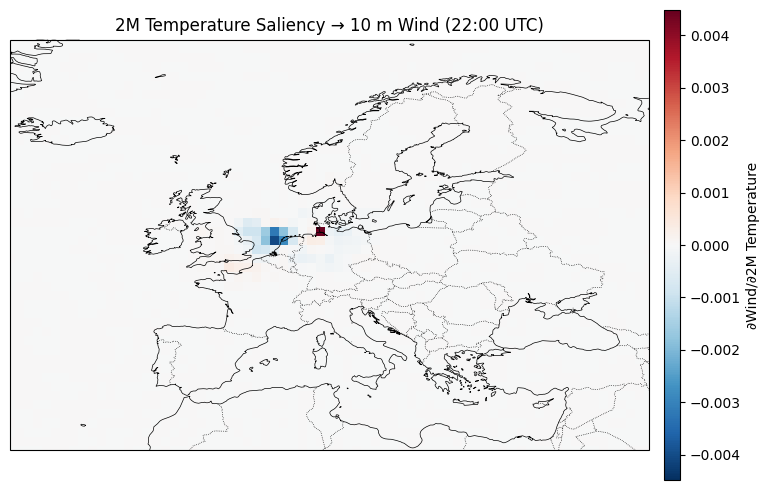

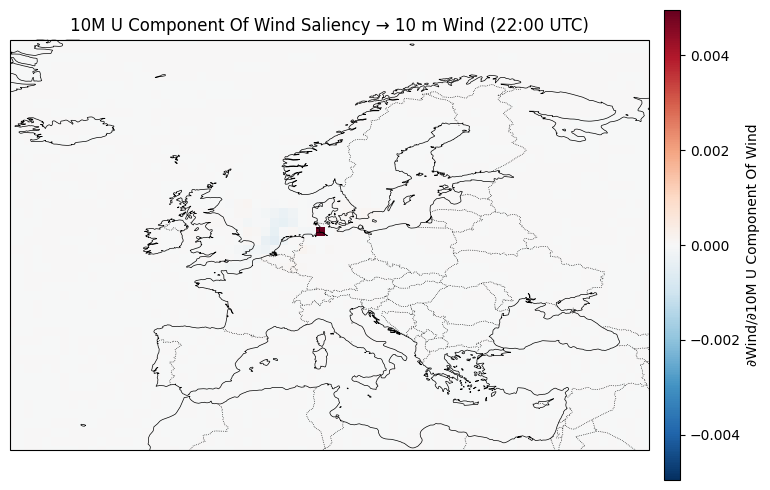

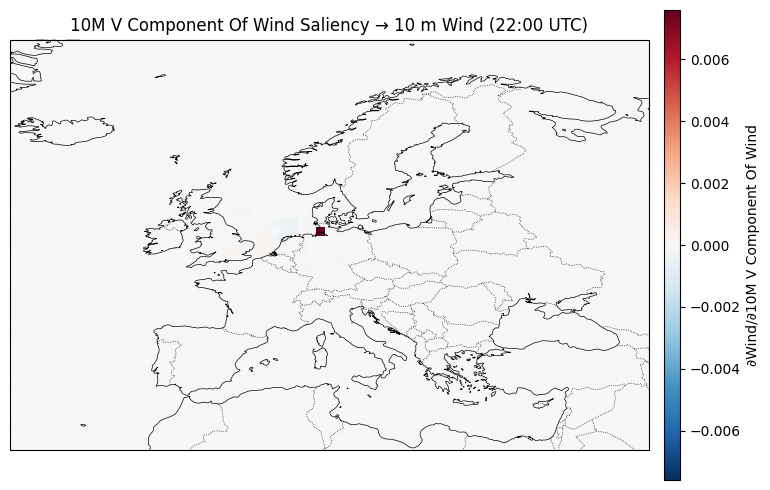

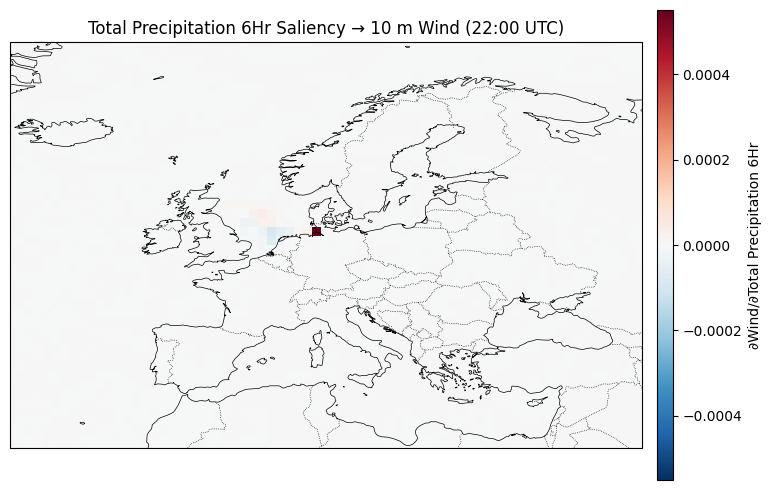

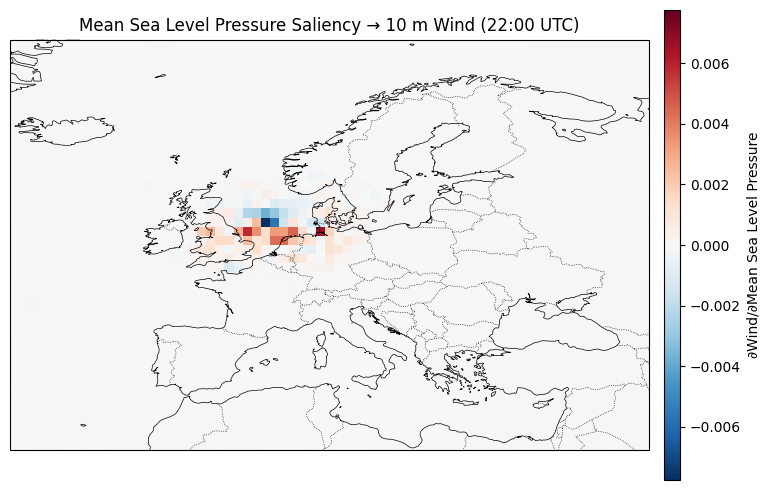

In [3]:
for surf_var in [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation_6hr",
    "mean_sea_level_pressure"
]:
    plot_surface_saliency(sal_ds_integrated_gradients, input_ds, surf_var, time_index=-2)

### Vanilla Gradient + Grad x Input
Positive values: increase of input = increase of output

Negative values: increase of input = decrease of the output

### Integrated Gradient
Positive values: feature enhances the predicted output relative to the baseline,

Negative value: feature suppresses the predicted output relative to the baseline.

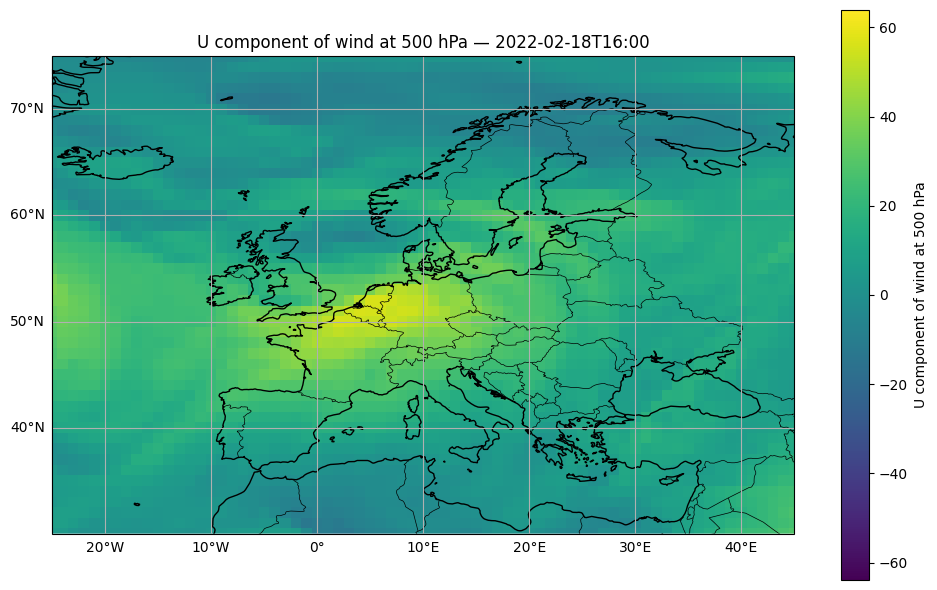

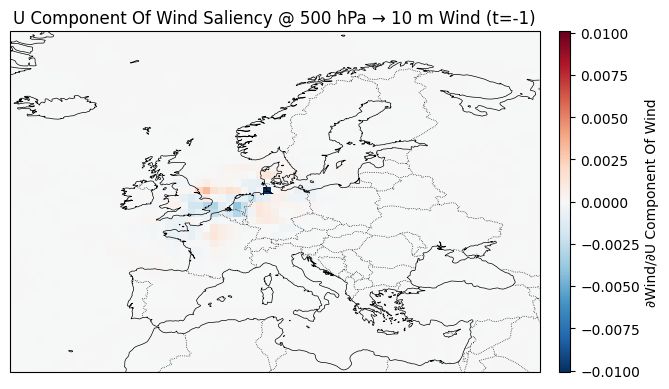

In [23]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

varname = "u_component_of_wind"
level = 500
time = -1
extent=[-25, 45, 30, 75]


plot_field(input_ds, time=(time+2), level=level, var_name=varname, extent=extent)

# plot_atmospheric_saliency(
#     sal_ds=sal_ds,
#     input_ds=input_ds,
#     varname=varname,
#     target_level=level,
#     time_index=time,
#     batch_index=0,
#     extent=extent,
#     cmap="RdBu_r"
# )

# plot_atmospheric_saliency(
#     sal_ds=sal_ds_grad_x_input,
#     input_ds=input_ds,
#     varname=varname,
#     target_level=level,
#     time_index=time,
#     batch_index=0,
#     extent=extent,
#     cmap="RdBu_r"
# )

plot_atmospheric_saliency(
    sal_ds=sal_ds_integrated_gradients,
    input_ds=input_ds,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent,
    cmap="RdBu_r"
)